# Pete Crow-Armstrong's 2026 Season: An Exploratory Analysis

**Question:** Is PCA's 2026 season a genuine breakout, and how does it stack up against historic Cubs seasons like Sammy Sosa's 1998 or Ryne Sandberg's 1984?

**Data sources:** MLB Statcast via `pybaseball` , Fangraphs


**PCA's season statistics may change as the 2026 regular season has not concluded. Last updated September 14th, 2026.**

## 0. Setup

This is the setup for the data analysis. We first must import pandas, matplotlib, and seaborn. We will use nympy later in the project. 

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

game_level = pd.read_csv("../data/processed/pca_game_level_2026.csv", parse_dates=["game_date"])
pa_df = pd.read_csv("../data/processed/pca_plate_appearances_2026.csv", parse_dates=["game_date"])
game_level.head()

# Shows the first few rows of the game_level dataframe, which contains information about each game played in the 2026 season. 
# The parse_dates parameter ensures that the "game_date" column is interpreted as a datetime object for easier analysis and visualization.

,game_date,at_bats,hits,home_runs,walks,strikeouts,stolen_bases,batting_avg_game,cum_hits,cum_at_bats,cum_avg,cum_home_runs,cum_stolen_bases,rolling_avg_7g,rolling_avg_30g,month
0,2026-03-26,5,2,0,0,2,0,0.400,2,5,0.400,0,0,NaN,NaN,March
1,2026-03-28,4,2,0,1,1,0,0.500,4,9,0.444,0,0,NaN,NaN,March
2,2026-03-29,4,0,0,0,0,0,0.000,4,13,0.308,0,0,NaN,NaN,March
3,2026-03-30,3,1,0,1,1,0,0.333,5,16,0.312,0,0,NaN,NaN,March
4,2026-03-31,3,0,0,0,2,0,0.000,5,19,0.263,0,0,NaN,NaN,March


## 1. Season Trend: Is This Sustained or a Hot Streak?

We will now plot cumulative batting average and rolling averages across the season.

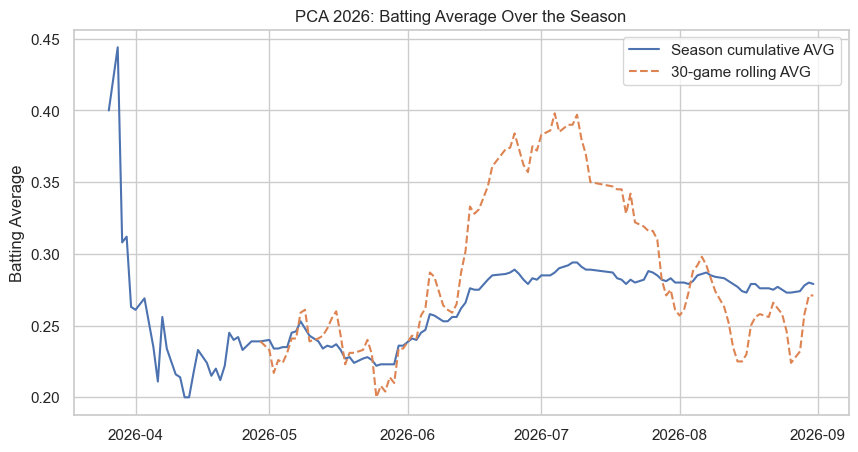

In [52]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(game_level["game_date"], game_level["cum_avg"], label="Season cumulative AVG")
ax.plot(game_level["game_date"], game_level["rolling_avg_30g"], label="30-game rolling AVG", linestyle="--")
ax.set_title("PCA 2026: Batting Average Over the Season")
ax.set_ylabel("Batting Average")
ax.legend()
plt.show()

Between June 2026 and August 2026, PCA had his best 30-game rolling AVG, with his peak in around July 2026.

In [53]:
game_level[["game_date", "cum_home_runs", "cum_stolen_bases"]].iloc[[0, 30, 60, 90, 120, -1]]


,game_date,cum_home_runs,cum_stolen_bases
0,2026-03-26,0,0
30,2026-05-01,3,0
60,2026-06-03,8,0
90,2026-07-09,21,0
120,2026-08-14,27,0
135,2026-08-31,38,0


Unfortunately, I noticed that Statcast does not have a metric that tracks stolen bases. So while I was able to pinpoint all of his batting stats, there is no way to check his stolen bases unless I accessed an external site like Fangraphs.

In [54]:
game_level[["game_date", "cum_avg", "rolling_avg_30g"]].tail(10)

,game_date,cum_avg,rolling_avg_30g
126,2026-08-21,0.276,0.256
127,2026-08-22,0.275,0.266
128,2026-08-23,0.277,0.262
129,2026-08-24,0.275,0.258
130,2026-08-25,0.273,0.246
131,2026-08-26,0.273,0.224
132,2026-08-28,0.274,0.232
133,2026-08-29,0.278,0.258
134,2026-08-30,0.280,0.271
135,2026-08-31,0.279,0.271


This looks at his most recent 10 games. He is currently sitting at around 0.276 batting average with a rolling average of around 0.256.

In [55]:
game_level[["game_date", "cum_avg", "rolling_avg_30g"]].head(10)

,game_date,cum_avg,rolling_avg_30g
0,2026-03-26,0.400,NaN
1,2026-03-28,0.444,NaN
2,2026-03-29,0.308,NaN
3,2026-03-30,0.312,NaN
4,2026-03-31,0.263,NaN
5,2026-04-01,0.261,NaN
6,2026-04-03,0.269,NaN
7,2026-04-05,0.235,NaN
8,2026-04-06,0.211,NaN
9,2026-04-07,0.256,NaN


This looks at his first 10 games. The batting average fluctuates because of the low amount of plate appearances.

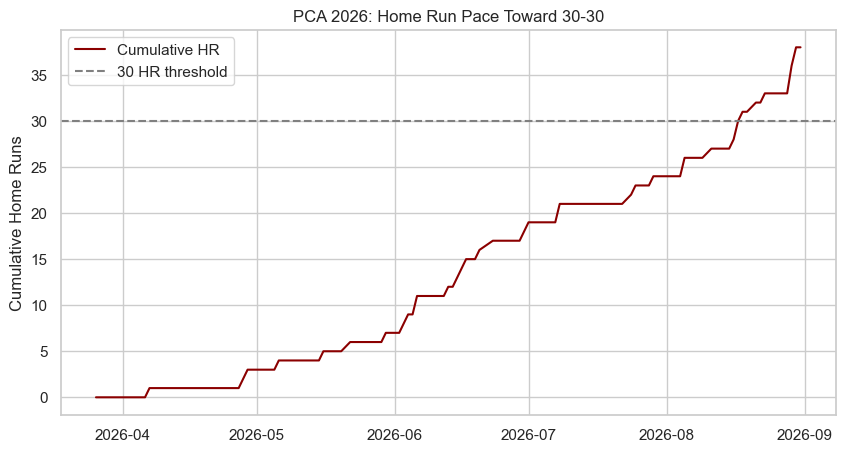

Quick Note: Season SB total (from FanGraphs): 36 — 30-30 season confirmed via home runs + season-total stolen bases.


In [56]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(game_level["game_date"], game_level["cum_home_runs"], label="Cumulative HR", color="darkred")
ax.axhline(30, color="gray", linestyle="--", label="30 HR threshold")
ax.set_title("PCA 2026: Home Run Pace Toward 30-30")
ax.set_ylabel("Cumulative Home Runs")
ax.legend()
plt.show()
print("Quick Note: Season SB total (from FanGraphs): 36 — 30-30 season confirmed via home runs + season-total stolen bases.")

The graph clearly seems to show exponential growth. From April to July, the HRs seems to come weekly, as noted by the long horizontal lines in the graph. However, between July to September, we can see that the line jumps way more often, indicating a spike in slugging production.

## 2. Splits Analysis And Defensive Stats

 We will now look at how PCA performs against Left-Handed Pitchers vs Right-Handed Pitchers. We will then look at defensive stats including Defensive WAR (dWAR) and Outs Above Average (OAA).

In [57]:
splits = (
    pa_df.groupby("p_throws")
    .agg(at_bats=("at_bat", "sum"), hits=("is_hit", "sum"), home_runs=("is_home_run", "sum"))
    .assign(avg=lambda d: (d["hits"] / d["at_bats"]).round(3))
)
splits

,at_bats,hits,home_runs,avg
p_throws,,,,
L,172,53,11,0.308
R,366,97,27,0.265


 PCA performs better against Left-Handed Pitchers than Right-Handed Pitchers, but he does face Right-Handed Pitchers more often.

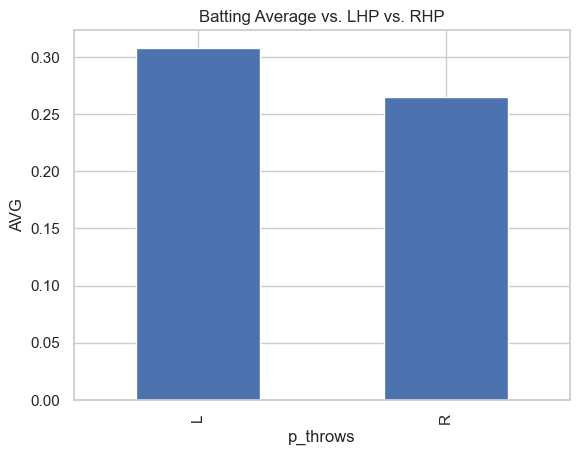

In [58]:
splits["avg"].plot(kind="bar", title="Batting Average vs. LHP vs. RHP", ylabel="AVG")
plt.show()

Now we can look at his defensive stats. Lets look at the statcast OAA.

In [59]:
from pybaseball import statcast_outs_above_average

pca_oaa = statcast_outs_above_average(2026, "of")
pca_oaa = pca_oaa[pca_oaa["last_name, first_name"].str.contains("Crow-Armstrong", na=False)]
print(pca_oaa)

   last_name, first_name  player_id display_team_name  year  \
26  Crow-Armstrong, Pete     691718              Cubs  2026   

   primary_pos_formatted  fielding_runs_prevented  outs_above_average  \
26                    CF                       23                  26   

    outs_above_average_infront  outs_above_average_lateral_toward3bline  \
26                           2                                       11   

    outs_above_average_lateral_toward1bline  outs_above_average_behind  \
26                                       11                          2   

    outs_above_average_rhh  outs_above_average_lhh  \
26                      18                       8   

   actual_success_rate_formatted adj_estimated_success_rate_formatted  \
26                           96%                                  90%   

   diff_success_rate_formatted  
26                          6%  


Statcast's own defensive metric confirms this is 
elite. PCA posted 26 Outs Above Average, in center field in 2026, one of the best marks among all MLB outfielders with a 96% actual catch success rate. When diving further, we can see that this ties the Statcast record for most OAA in a single season by an outfielder! 

In [60]:
pca_defense = pd.DataFrame([
    {"Player": "Pete Crow-Armstrong", "Season": 2026, "WAR": 9.8, "Def_runs": 23.1, "dWAR_approx": round(23.1 / 10, 1), "OAA": 26},
])
pca_defense

#Statistics were acquired from FanGraphs and Statcast. The dWAR_approx is a rough estimate of defensive WAR based on runs above average, assuming 10 runs above average roughly equates to 1 WAR.

,Player,Season,WAR,Def_runs,dWAR_approx,OAA
0,Pete Crow-Armstrong,2026,9.8,23.1,2.3,26


While looking at the dataframe, we can see that he accounted for 23.1 defensive runs prevented. Also, according  he produced a WAR of around 9.8, with an a exceptional dWAR approximation of  2.3. This means, on average, PCA's defense by itself added around 2.3 wins to the 2026 Chicago Cubs season. Insane! 

## 3. Historical Comparison

Compare PCA's counting stats at this point in the season to Sosa's 1998 and Sandberg's 1984 season. 

In [61]:
comparison_offense = pd.DataFrame([
    {"Player": "Pete Crow-Armstrong", "Season": 2026, "HR": 41, "SB": 36, "AVG": 0.277},
    #PCA 2026 stats are based on the 2026 season data. Last updated Monday September 14th, 2026.
    {"Player": "Sammy Sosa", "Season": 1998, "HR": 66, "SB": 18, "AVG": 0.308},
    {"Player": "Ryne Sandberg", "Season": 1984, "HR": 19, "SB": 32, "AVG": 0.314},
])
comparison_offense

,Player,Season,HR,SB,AVG
0,Pete Crow-Armstrong,2026,41,36,0.277
1,Sammy Sosa,1998,66,18,0.308
2,Ryne Sandberg,1984,19,32,0.314


This is the HR, SB, and AVG comparison. PCA's stats can still change in last few weeks of the season, but we can see that Sosa and Sandbergs Batting Average is higher than PCA's, while PCA has the most SB. If we combine SB + HR, we can see that Sosa leads with 84, then PCA with 77, and lastly Sandberg with 51. 

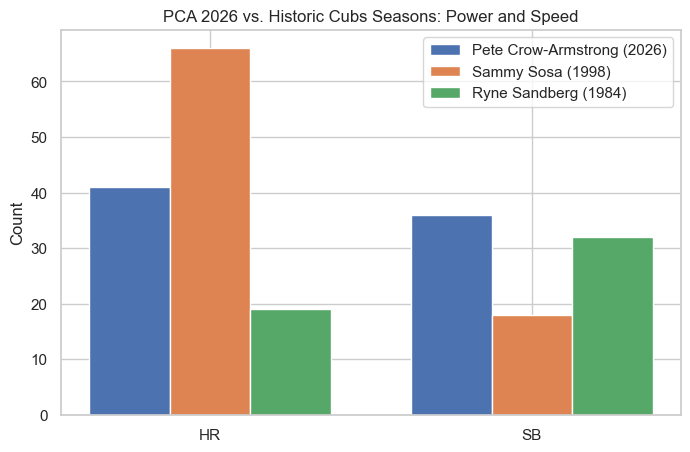

In [62]:
metrics = ["HR", "SB"]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, row in comparison_offense.iterrows():
    ax.bar(x + i * width, row[metrics], width, label=f"{row['Player']} ({row['Season']})")

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_title("PCA 2026 vs. Historic Cubs Seasons: Power and Speed")
ax.set_ylabel("Count")
ax.legend()
plt.show()

Like we dicussed earlier, Sosa leads in HR + SB but PCA is not far behind. It seems to be that PCA is more balanced when it comes to his HR and SB combination. Now we will look at WAR, Defensive Runs Saved, and dWAR.

In [64]:
from pybaseball import bwar_bat

war_data = bwar_bat()
sosa_1998 = war_data[(war_data["name_common"].str.contains("Sosa", na=False)) & (war_data["year_ID"] == 1998)]
sandberg_1984 = war_data[(war_data["name_common"].str.contains("Sandberg", na=False)) & (war_data["year_ID"] == 1984)]

print(sosa_1998)
print(sandberg_1984)

       name_common    mlb_ID player_ID  year_ID team_ID  stint_ID lg_ID  \
107046  Sammy Sosa  122544.0  sosasa01     1998     CHC         1    NL   

       pitcher    G   PA     salary  runs_above_avg  runs_above_avg_off  \
107046       N  159  722  8325000.0            46.2                43.6   

        runs_above_avg_def  WAR_rep   WAA   WAR  
107046                -3.2     2.09  4.37  6.46  
          name_common    mlb_ID  player_ID  year_ID team_ID  stint_ID lg_ID  \
100225  Ryne Sandberg  121665.0  sandbry01     1984     CHC         1    NL   

       pitcher    G   PA  salary  runs_above_avg  runs_above_avg_off  \
100225       N  156  700     NaN            57.3                45.1   

        runs_above_avg_def  WAR_rep   WAA   WAR  
100225                17.9     2.25  6.27  8.52  


In [65]:
print(sosa_1998[["name_common", "runs_above_avg_def"]])
print(sandberg_1984[["name_common", "runs_above_avg_def"]])
print("PCA 2026 Def (from FanGraphs): 23.1")

       name_common  runs_above_avg_def
107046  Sammy Sosa                -3.2
          name_common  runs_above_avg_def
100225  Ryne Sandberg                17.9
PCA 2026 Def (from FanGraphs): 23.1


In [66]:
comparison_defense = pd.DataFrame([
    {"Player": "Pete Crow-Armstrong", "Season": 2026, "WAR": 9.80, "Def_runs": 23.1, "dWAR_approx": round(23.1 / 10, 1)},
    {"Player": "Sammy Sosa", "Season": 1998, "WAR": 6.46, "Def_runs": -3.2, "dWAR_approx": round(-3.2 / 10, 1)},
    {"Player": "Ryne Sandberg", "Season": 1984, "WAR": 8.52, "Def_runs": 17.9, "dWAR_approx": round(17.9 / 10, 1)},
])
comparison_defense

,Player,Season,WAR,Def_runs,dWAR_approx
0,Pete Crow-Armstrong,2026,9.80,23.1,2.3
1,Sammy Sosa,1998,6.46,-3.2,-0.3
2,Ryne Sandberg,1984,8.52,17.9,1.8


We can see that PCA leads in all three categories. While Sandberg is not too far behind, Sosa seems to be a defensive liability.

## 4. Takeaway




#### I believe PCA is having one of the best individual seasons in Chicago Cubs history. Looking at his batting stats, it is fair  to say that his increase in production is not a fluke. His batting average and HR steadily increased until it hit a spot during June where it skyrocketed. And it is not just his offense either. Defensively, his OAA and dWAR are so high that the OAA tied a record for most in a single season for an outfielder. When comparing to some of the greatest Chicago Cubs players, almost all of his stats keep up with the legends Sammy Sosa and Ryne Sandberg. #### 